# Silhouette Evaluation (Contours + Edge) — Google Colab

This notebook replicates the backend evaluation pipeline for weighted silhouette scoring (area, aspect, vertical alignment, solidity, border) to measure bottle dimensions and volume.

- Uses dataset images from `testing/second/*` (simple + complex)
- Supports debug overlays and summary metrics (MAE, MRE, RMSE)
- Optional parameter sweeps (single-parameter and combinations)
- Optional Roboflow ROI fusion (disabled by default)

References:
- `docs/Silhouette_Parameter_Tuning_Automation.md`
- Backend implementation in `backend/src/backend/services/opencv_service.py` and `backend/src/backend/tools/eval_silhouette.py`

Tip: Mount Google Drive and place your dataset at `MyDrive/compfest/testing/second` for fastest iteration on Colab.


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
#@title Imports
import os, io, math, json, zipfile
from dataclasses import dataclass
from typing import Optional, List, Tuple, Any

import numpy as np
import cv2
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


In [15]:
#@title Install dependencies
import sys, subprocess
pkgs = [
    'opencv-python-headless==4.10.0.84',
    'numpy', 'pandas', 'tqdm', 'matplotlib', 'ipywidgets', 'Pillow'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)


0

In [16]:
#@title Mount / Configure dataset root
from pathlib import Path

# Detect Colab
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Point to the directory that contains `second/`
if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)
    DEFAULT_ROOT = Path('/content/drive/MyDrive/compfest')
else:
    DEFAULT_ROOT = Path('.')

REPO_ROOT = Path(input('Enter path to repo root (contains second) or leave blank for default: ').strip() or DEFAULT_ROOT)
DATA_ROOT = REPO_ROOT / 'second'

assert DATA_ROOT.exists(), f"Dataset not found at: {DATA_ROOT}"
print('Using DATA_ROOT =', DATA_ROOT)


Mounted at /content/drive
Enter path to repo root (contains second) or leave blank for default: 
Using DATA_ROOT = /content/drive/MyDrive/compfest/second


In [17]:
#@title Roboflow setup (for ROI fusion)
# Configure Roboflow if you want to enable USE_FUSION.
# By default, the notebook runs without external calls.

USE_ROBOFLOW = True #@param {type: 'boolean'}
ROBOFLOW_API_KEY = 'GnOMdIkigFOvGVQvYzIO' #@param {type: 'string'}
# Format: <model_name>/<version> (matching backend config)
ROBOFLOW_MODEL_ID = 'klasifikasi-per-merk/3' #@param {type: 'string'}

if USE_ROBOFLOW and ROBOFLOW_API_KEY:
    !pip -q install inference-sdk
    from inference_sdk import InferenceHTTPClient
    import numpy as np
    from PIL import Image
    import io

    # This matches your backend RoboflowClient implementation
    class RoboflowClient:
        def __init__(self, api_key: str, model_id: str):
            self.api_key = api_key
            self.model_id = model_id
            self._client = InferenceHTTPClient(
                api_url="https://serverless.roboflow.com",
                api_key=api_key,
            )

        async def predict(self, image_bytes: bytes):
            # Convert bytes to numpy array (matching backend)
            try:
                pil_image = Image.open(io.BytesIO(image_bytes))
                image_np = np.array(pil_image)
            except Exception as exc:
                print(f"Failed to decode image bytes: {exc}")
                return []

            try:
                # Use the SDK directly (matching backend)
                data = self._client.infer(image_np, model_id=self.model_id)
                predictions_data = data.get("predictions", [])

                # Simple prediction objects for compatibility
                predictions = []
                for p in predictions_data:
                    pred = type('Prediction', (), {})()
                    pred.x = p.get('x')
                    pred.y = p.get('y')
                    pred.width = p.get('width')
                    pred.height = p.get('height')
                    pred.confidence = p.get('confidence', 0.0)
                    predictions.append(pred)

                return predictions
            except Exception as exc:
                print(f"Roboflow error: {exc}")
                return []

    # Create client instance
    roboflow_client = RoboflowClient(ROBOFLOW_API_KEY, ROBOFLOW_MODEL_ID)
    print(f'Roboflow client ready: {ROBOFLOW_MODEL_ID}')
else:
    roboflow_client = None
    print('Roboflow disabled.')

Roboflow client ready: klasifikasi-per-merk/3


In [27]:
#@title Config: evaluation, weights, fusion
from dataclasses import asdict

SUBSET = 'both' #@param ['simple', 'complex', 'both']
LIMIT = 0        #@param {type: 'number'}
LIMIT_PER_FOLDER = 0  #@param {type: 'number'}
SAVE_DEBUG = True #@param {type: 'boolean'}
USE_FUSION = True #@param {type: 'boolean'}
OUT_DIR = Path('./colab_eval_out')

# Scoring weights
W_AREA = 0.7     #@param {type: 'number'}
W_ASPECT = 1.8   #@param {type: 'number'}
W_VERTICAL = 1.6 #@param {type: 'number'}
W_SOLIDITY = 0.9 #@param {type: 'number'}
W_BORDER = 1.4   #@param {type: 'number'}

RUN_DIR = OUT_DIR / 'silhouette_experiments'
RUN_DIR.mkdir(parents=True, exist_ok=True)

def save_run_config(run_path: Path):
    cfg = {
        'fusion': bool(USE_FUSION),
        'weights': {
            'area': float(W_AREA),
            'aspect': float(W_ASPECT),
            'vertical': float(W_VERTICAL),
            'solidity': float(W_SOLIDITY),
            'border': float(W_BORDER),
        },
        'subset': SUBSET,
        'limit': int(LIMIT),
        'limit_per_folder': int(LIMIT_PER_FOLDER),
    }
    (run_path / 'run_config.json').write_text(json.dumps(cfg, indent=2))
    return cfg

print('Weights:', W_AREA, W_ASPECT, W_VERTICAL, W_SOLIDITY, W_BORDER)


Weights: 0.7 1.8 1.6 0.9 1.4


In [19]:
from typing import Iterable, Optional, List

def parse_expected_from_dir(p: Path) -> Optional[float]:
    label = p.parent.name.lower()
    digits = ''.join([c for c in label if c.isdigit()])
    if not digits:
        return None
    try:
        return float(digits)
    except Exception:
        return None

def list_images(roots: List[Path], limit: int = 0, limit_per_folder: int = 0) -> List[Path]:
    exts = {'.jpg', '.jpeg', '.png', '.heic'}
    images: List[Path] = []
    if limit_per_folder and limit_per_folder > 0:
        for r in roots:
            if not r.exists():
                continue
            for sub in sorted([p for p in r.iterdir() if p.is_dir()]):
                files = sorted([p for p in sub.iterdir() if p.suffix.lower() in exts])
                images.extend(files[:limit_per_folder])
    else:
        for r in roots:
            if not r.exists():
                continue
            for ext in exts:
                images.extend(sorted(r.rglob(f'*{ext}')))
    if limit and limit > 0:
        images = images[:limit]
    return images

def imread_bytes(p: Path) -> bytes:
    return Path(p).read_bytes()

In [20]:
#@title Core: Detector and Measurer (ported from backend)

from dataclasses import dataclass
from typing import Optional, List, Tuple, Any
import numpy as np

@dataclass
class MeasurementResult:
    diameter_mm: float
    height_mm: float
    volume_ml: float
    classification: Optional[str] = None
    confidence_percent: Optional[float] = None

class MeasurementError(RuntimeError):
    pass

@dataclass
class PixelBottleInfo:
    pixel_width: float
    pixel_height: float
    contour: np.ndarray
    box_points: np.ndarray

#@title EXACT 1:1 Backend Implementation - Replace your entire BottleDetector and BottleMeasurer classes

import logging
from dataclasses import dataclass
from typing import Optional, List, Tuple, Any, Union
import numpy as np
import cv2
import math

# Set up basic logging since we can't import the backend logger
logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger(__name__)

@dataclass
class MeasurementResult:
    diameter_mm: float
    height_mm: float
    volume_ml: float
    classification: Optional[str] = None
    confidence_percent: Optional[float] = None

class MeasurementError(RuntimeError):
    pass

@dataclass
class PixelBottleInfo:
    pixel_width: float
    pixel_height: float
    contour: np.ndarray
    box_points: np.ndarray

class BottleDetector:
    """Detect an upright bottle inside a Region-Of-Interest using edge analysis.

    Implements a multi-path silhouette extraction and weighted contour scoring
    inspired by docs/Scanning_and_Measurement_Improvements.md.
    """

    def __init__(
        self,
        *,
        min_aspect_ratio: float = 1.2,
        max_tilt_deg: float = 20.0,
        # scoring weights (all non-negative, they are normalized relatively)
        weight_area: float = 1.0,
        weight_aspect: float = 1.0,
        weight_vertical: float = 1.0,
        weight_solidity: float = 1.0,
        weight_border: float = 0.5,
    ) -> None:
        self.min_aspect_ratio = min_aspect_ratio
        self.max_tilt_deg = max_tilt_deg
        self.weights = {
            "area": max(0.0, float(weight_area)),
            "aspect": max(0.0, float(weight_aspect)),
            "vertical": max(0.0, float(weight_vertical)),
            "solidity": max(0.0, float(weight_solidity)),
            "border": max(0.0, float(weight_border)),
        }

    # --- internal helpers ----------------------------------------------------
    @staticmethod
    def _to_gray(roi: np.ndarray) -> np.ndarray:
        if roi.ndim == 3:
            return cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        return roi

    @staticmethod
    def _morph_close(bin_img: np.ndarray, k: int = 5, iters: int = 1) -> np.ndarray:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
        return cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, kernel, iterations=iters)

    def _pipeline_candidates(self, roi: np.ndarray) -> List[np.ndarray]:
        """Generate binary masks from multiple pipelines and return their contours.

        Pipelines:
        1) Adaptive threshold (Gaussian), then close/open
        2) Canny (hysteresis thresholds via MAD of gradients), then close
        3) CLAHE + Otsu threshold, then close
        4) new
        """
        gray = self._to_gray(roi)
        h, w = gray.shape[:2]
        candidates: List[np.ndarray] = []

        # 1) Adaptive threshold
        try:
            adp = cv2.adaptiveThreshold(
                gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 3
            )
            adp = self._morph_close(adp, 5, 1)
            contours, _ = cv2.findContours(adp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            candidates.extend(contours)
        except Exception:
            pass

        # 2) Canny with MAD-based thresholds
        try:
            gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
            gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
            mag = cv2.magnitude(gx, gy)
            med = float(np.median(mag))
            mad = float(np.median(np.abs(mag - med)) + 1e-6)
            low = max(5.0, 1.5 * mad)
            high = max(low + 10.0, 3.0 * mad)
            edges = cv2.Canny(gray, low, high)
            edges = self._morph_close(edges, 5, 1)
            contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            candidates.extend(contours)
        except Exception:
            pass

        # 3) CLAHE + Otsu
        try:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            eq = clahe.apply(gray)
            _, otsu = cv2.threshold(eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            otsu = self._morph_close(otsu, 5, 1)
            contours, _ = cv2.findContours(otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            candidates.extend(contours)
        except Exception:
            pass

        # 4) NEW: Plastic bottle specific pipeline
        try:
          # Bilateral filter to reduce noise while preserving edges
          bilateral = cv2.bilateralFilter(gray, 9, 75, 75)

          # Gradient-based detection for transparent edges
          grad_x = cv2.Sobel(bilateral, cv2.CV_16S, 1, 0, ksize=3)
          grad_y = cv2.Sobel(bilateral, cv2.CV_16S, 0, 1, ksize=3)
          abs_grad_x = cv2.convertScaleAbs(grad_x)
          abs_grad_y = cv2.convertScaleAbs(grad_y)
          gradient = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)

          # Threshold gradient
          _, grad_thresh = cv2.threshold(gradient, 30, 255, cv2.THRESH_BINARY)
          grad_thresh = self._morph_close(grad_thresh, 3, 2)

          contours, _ = cv2.findContours(grad_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
          candidates.extend(contours)
        except Exception:
            pass

        return candidates

    def _score_contour(self, cnt: np.ndarray, roi_shape: Tuple[int, int], *, min_area_px: int) -> float:
        h, w = roi_shape
        roi_area = float(h * w)
        area = float(cv2.contourArea(cnt))
        if area < float(min_area_px):  # hard gate: too small
            return -1e9

        rect = cv2.minAreaRect(cnt)
        (_, _), (wr, hr), angle = rect
        if wr <= 0 or hr <= 0:
            return -1e9
        visual_h = max(wr, hr)
        visual_w = min(wr, hr)
        if visual_w <= 0:
            return -1e9
        aspect = float(visual_h / visual_w)

        # Feature: area score (prefer in [min_area_px, 0.9 * roi_area])
        max_allowed = 0.9 * roi_area
        area_score = 0.0
        if area <= min_area_px:
            area_score = 0.0
        elif area >= max_allowed:
            area_score = 1.0
        else:
            area_score = (area - min_area_px) / max(1.0, (max_allowed - min_area_px))

        # Feature: aspect ratio (>= min_aspect_ratio) - IMPROVED for tall bottles
        aspect_score = 0.0
        if aspect >= self.min_aspect_ratio:
            # Favor very tall bottles (2.5+ aspect ratio) more
            if aspect >= 2.5:
                aspect_score = min(1.0, aspect / 4.0)  # Reward up to 4:1 ratio
            else:
                aspect_score = min(1.0, (aspect / max(1e-6, self.min_aspect_ratio)) / 3.0)
        else:
            aspect_score = max(0.0, (aspect / max(1e-6, self.min_aspect_ratio)) - 0.2)

        # Feature: vertical alignment score based on tilt
        if hr >= wr:
            tilt = abs(float(angle))
        else:
            tilt = abs(90.0 - abs(float(angle)))
        vertical_score = 1.0 - min(1.0, (tilt / max(1e-6, self.max_tilt_deg)) ** 2)

        # Feature: solidity (area / convex hull area)
        try:
            hull = cv2.convexHull(cnt)
            hull_area = float(cv2.contourArea(hull))
            solidity = 0.0 if hull_area <= 0 else float(area / hull_area)
        except Exception:
            solidity = 0.0
        solidity_score = float(np.clip(solidity, 0.0, 1.0))

        # Feature: border penalty -> score 1.0 when far from borders, 0 near borders
        x, y, bw, bh = cv2.boundingRect(cnt)
        margin = max(5, int(0.02 * min(w, h)))
        dist_left = x
        dist_top = y
        dist_right = w - (x + bw)
        dist_bottom = h - (y + bh)
        min_dist = float(min(dist_left, dist_top, dist_right, dist_bottom))
        border_score = float(np.clip(min_dist / float(margin), 0.0, 1.0))

        # NEW: Position feature (prefer bottles in center of frame)
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = M["m10"] / M["m00"]
            cy = M["m01"] / M["m00"]

            # Distance from center
            center_x, center_y = w / 2, h / 2
            dist_from_center = np.sqrt((cx - center_x)**2 + (cy - center_y)**2)
            max_dist = np.sqrt(center_x**2 + center_y**2)
            position_score = 1.0 - (dist_from_center / max_dist)
        else:
            position_score = 0.0

        # Weighted sum - FIXED to include position weight
        w_area = self.weights["area"]
        w_aspect = self.weights["aspect"]
        w_vert = self.weights["vertical"]
        w_sol = self.weights["solidity"]
        w_border = self.weights["border"]
        w_pos = 0.3  # NEW weight for position

        total_w = max(1e-6, (w_area + w_aspect + w_vert + w_sol + w_border + w_pos))
        score = (
            w_area * area_score
            + w_aspect * aspect_score
            + w_vert * vertical_score
            + w_sol * solidity_score
            + w_border * border_score
            + w_pos * position_score  # NOW PROPERLY DEFINED
        ) / total_w

        return float(score)

    def detect(self, roi: np.ndarray, min_area_px: int) -> PixelBottleInfo:
        contours = self._pipeline_candidates(roi)
        if not contours:
            raise MeasurementError("Bottle not found in ROI.")

        h, w = roi.shape[:2]
        best_cnt: Optional[np.ndarray] = None
        best_score = -1e9
        for cnt in contours:
            sc = self._score_contour(cnt, (h, w), min_area_px=min_area_px)
            if sc > best_score:
                best_score = sc
                best_cnt = cnt

        if best_cnt is None:
            raise MeasurementError("Bottle not found in ROI.")

        rect = cv2.minAreaRect(best_cnt)
        (_, _), (w_raw, h_raw), _ = rect
        visual_h = max(w_raw, h_raw)
        visual_w = min(w_raw, h_raw)
        box = np.intp(cv2.boxPoints(rect))
        return PixelBottleInfo(
            pixel_width=float(visual_w),
            pixel_height=float(visual_h),
            contour=best_cnt,
            box_points=box,
        )

    def detect_with_debug(self, roi: np.ndarray, min_area_px: int) -> Tuple[PixelBottleInfo, bytes]:
        """Same as detect() but returns debug visualization of all pipelines."""
        gray = self._to_gray(roi)
        h, w = gray.shape[:2]

        # Store all dmasks and their contours
        pipeline_masks = {}
        pipeline_contours = {}
        all_candidates = []

        # 1) Adaptive threshold
        try:
            adp = cv2.adaptiveThreshold(
                gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 3
            )
            adp_closed = self._morph_close(adp, 5, 1)
            contours, _ = cv2.findContours(adp_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            pipeline_masks['adaptive'] = adp_closed
            pipeline_contours['adaptive'] = contours
            all_candidates.extend(contours)
        except Exception:
            pipeline_masks['adaptive'] = np.zeros_like(gray)
            pipeline_contours['adaptive'] = []

        # 2) Canny with MAD-based thresholds
        try:
            gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
            gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
            mag = cv2.magnitude(gx, gy)
            med = float(np.median(mag))
            mad = float(np.median(np.abs(mag - med)) + 1e-6)
            low = max(5.0, 1.5 * mad)
            high = max(low + 10.0, 3.0 * mad)
            edges = cv2.Canny(gray, low, high)
            edges_closed = self._morph_close(edges, 5, 1)
            contours, _ = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            pipeline_masks['canny'] = edges_closed
            pipeline_contours['canny'] = contours
            all_candidates.extend(contours)
        except Exception:
            pipeline_masks['canny'] = np.zeros_like(gray)
            pipeline_contours['canny'] = []

        # 3) CLAHE + Otsu
        try:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            eq = clahe.apply(gray)
            _, otsu = cv2.threshold(eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            otsu_closed = self._morph_close(otsu, 5, 1)
            contours, _ = cv2.findContours(otsu_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            pipeline_masks['clahe_otsu'] = otsu_closed
            pipeline_contours['clahe_otsu'] = contours
            all_candidates.extend(contours)
        except Exception:
            pipeline_masks['clahe_otsu'] = np.zeros_like(gray)
            pipeline_contours['clahe_otsu'] = []

        if not all_candidates:
            raise MeasurementError("Bottle not found in ROI.")

        # Score all candidates and find best
        best_cnt: Optional[np.ndarray] = None
        best_score = -1e9
        candidate_scores = []

        for cnt in all_candidates:
            sc = self._score_contour(cnt, (h, w), min_area_px=min_area_px)
            candidate_scores.append((cnt, sc))
            if sc > best_score:
                best_score = sc
                best_cnt = cnt

        if best_cnt is None:
            raise MeasurementError("Bottle not found in ROI.")

        # Create debug visualization
        debug_img = self._create_pipeline_debug(
            roi, gray, pipeline_masks, pipeline_contours,
            best_cnt, candidate_scores, min_area_px
        )

        # Encode debug image
        _, debug_buf = cv2.imencode('.jpg', debug_img)
        debug_bytes = debug_buf.tobytes()

        # Return same result as regular detect()
        rect = cv2.minAreaRect(best_cnt)
        (_, _), (w_raw, h_raw), _ = rect
        visual_h = max(w_raw, h_raw)
        visual_w = min(w_raw, h_raw)
        box = np.intp(cv2.boxPoints(rect))

        result = PixelBottleInfo(
            pixel_width=float(visual_w),
            pixel_height=float(visual_h),
            contour=best_cnt,
            box_points=box,
        )

        return result, debug_bytes

    def _create_pipeline_debug(self, roi, gray, pipeline_masks, pipeline_contours,
                              best_cnt, candidate_scores, min_area_px):
        """Create comprehensive debug visualization."""
        h, w = roi.shape[:2]

        # Create 2x3 grid: Original + 3 masks + candidates + final result
        cell_h, cell_w = h, w
        debug_img = np.zeros((cell_h * 2, cell_w * 3, 3), dtype=np.uint8)

        # Row 1: Original + 3 pipeline masks
        # Original ROI (top-left)
        if roi.ndim == 3:
            debug_img[0:cell_h, 0:cell_w] = roi
        else:
            debug_img[0:cell_h, 0:cell_w] = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        cv2.putText(debug_img, "Original ROI", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Adaptive mask (top-center)
        adaptive_bgr = cv2.cvtColor(pipeline_masks['adaptive'], cv2.COLOR_GRAY2BGR)
        debug_img[0:cell_h, cell_w:cell_w*2] = adaptive_bgr
        cv2.putText(debug_img, f"Adaptive ({len(pipeline_contours['adaptive'])} cnt)",
                    (cell_w+5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1)

        # Canny mask (top-right)
        canny_bgr = cv2.cvtColor(pipeline_masks['canny'], cv2.COLOR_GRAY2BGR)
        debug_img[0:cell_h, cell_w*2:cell_w*3] = canny_bgr
        cv2.putText(debug_img, f"Canny ({len(pipeline_contours['canny'])} cnt)",
                    (cell_w*2+5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1)

        # Row 2: CLAHE+Otsu + All candidates + Final result
        # CLAHE+Otsu mask (bottom-left)
        clahe_bgr = cv2.cvtColor(pipeline_masks['clahe_otsu'], cv2.COLOR_GRAY2BGR)
        debug_img[cell_h:cell_h*2, 0:cell_w] = clahe_bgr
        cv2.putText(debug_img, f"CLAHE+Otsu ({len(pipeline_contours['clahe_otsu'])} cnt)",
                    (5, cell_h+20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1)

        # All candidates with scores (bottom-center)
        candidates_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) if roi.ndim == 3 else roi.copy()
        colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255), (0,255,255)]

        # Sort by score to show best ones prominently
        sorted_candidates = sorted(candidate_scores, key=lambda x: x[1], reverse=True)[:10]

        for i, (cnt, score) in enumerate(sorted_candidates):
            if score < -1e8:  # Skip invalid contours
                continue
            color = colors[i % len(colors)]
            thickness = 3 if cnt is best_cnt else 1
            cv2.drawContours(candidates_img, [cnt], -1, color, thickness)

            # Show score near contour
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = M["m10"] / M["m00"]
                cy = M["m01"] / M["m00"]

                # Distance from center
                center_x, center_y = w / 2, h / 2
                dist_from_center = np.sqrt((cx - center_x)**2 + (cy - center_y)**2)
                max_dist = np.sqrt(center_x**2 + center_y**2)
                position_score = 1.0 - (dist_from_center / max_dist)
            else:
                position_score = 0.0

        debug_img[cell_h:cell_h*2, cell_w:cell_w*2] = candidates_img
        cv2.putText(debug_img, f"Candidates (min_area:{min_area_px}px)",
                    (cell_w+5, cell_h+20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Final result with best contour (bottom-right)
        final_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) if roi.ndim == 3 else roi.copy()
        cv2.drawContours(final_img, [best_cnt], -1, (0, 255, 0), 2)

        # Draw bounding box
        rect = cv2.minAreaRect(best_cnt)
        box = np.intp(cv2.boxPoints(rect))
        cv2.drawContours(final_img, [box], -1, (255, 0, 0), 2)

        debug_img[cell_h:cell_h*2, cell_w*2:cell_w*3] = final_img
        cv2.putText(debug_img, f"CHOSEN (score:{best_score:.2f})",
                    (cell_w*2+5, cell_h+20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        return debug_img


class BottleMeasurer:
    """Measure bottle dimensions using a coloured reference object for scale calibration.

    The algorithm expects a solid-colour reference rectangle (or any blob) at the
    bottom of the frame. Region of interest (ROI) above that reference will be
    analysed to detect the bottle silhouette.
    """

    def __init__(
        self,
        # Real-world height of the coloured reference marker in millimetres.
        ref_real_height_mm: float = 160.0,
        *,
        ref_real_width_mm: Optional[float] = None,  # legacy alias, optional
        ref_hsv_lower: Tuple[int, int, int] = (0, 0, 0),    # black lower HSV
        ref_hsv_upper: Tuple[int, int, int] = (180, 255, 50),  # black upper HSV
        # NEW parameters ------------------------------------------------------
        classify: bool = True,
        known_bottle_specs: Optional[dict] = None,
        tolerance_percent: float = 30.0,
        # Detector weighting parameters (silhouette scoring)
        detector_weight_area: float = 1.0,
        detector_weight_aspect: float = 1.0,
        detector_weight_vertical: float = 1.0,
        detector_weight_solidity: float = 1.0,
        detector_weight_border: float = 0.5,
    ) -> None:
        if ref_real_width_mm is not None:
            # Provided via legacy param name – treat it as height value to
            # maintain the original behaviour for callers that pass only a
            # positional value.
            ref_real_height_mm = ref_real_width_mm

        self.ref_real_height_mm = ref_real_height_mm
        self.ref_hsv_lower = np.array(ref_hsv_lower, dtype=np.uint8)
        self.ref_hsv_upper = np.array(ref_hsv_upper, dtype=np.uint8)
        # Advanced pipeline configuration ------------------------------------
        self.classify = classify
        self.known_specs = (
            known_bottle_specs
            if known_bottle_specs is not None
            else {
                "200mL": {"volume_ml": 200},
                "500mL": {"volume_ml": 500},
                "600mL": {"volume_ml": 600},  # Added to match payout service expectations
                "1000mL": {"volume_ml": 1000},
            }
        )
        self.tolerance_percent = tolerance_percent
        self.detector = BottleDetector(
            min_aspect_ratio=1.2,
            max_tilt_deg=20.0,
            weight_area=detector_weight_area,
            weight_aspect=detector_weight_aspect,
            weight_vertical=detector_weight_vertical,
            weight_solidity=detector_weight_solidity,
            weight_border=detector_weight_border,
        )

    def _find_reference(self, hsv: np.ndarray) -> Tuple[int, int, int, int]:
        """Return bounding box (x, y, w, h) of reference object in HSV image."""
        mask = cv2.inRange(hsv, self.ref_hsv_lower, self.ref_hsv_upper)
        # Morphological cleanup
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            raise MeasurementError("Reference object not found in image.")
        # Choose the largest contour as reference
        contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(contour)
        if w < 10 or h < 10:  # sanity check
            raise MeasurementError("Reference object size too small.")
        logger.debug("Reference bbox: x=%d y=%d w=%d h=%d", x, y, w, h)
        return x, y, w, h

    def measure(
        self,
        image_bytes: bytes,
        *,
        predictions: Optional[List[Any]] = None,
        return_debug: bool = False,
    ) -> Union[MeasurementResult, Tuple[MeasurementResult, bytes]]:
        # Decode image bytes to BGR
        nparr = np.frombuffer(image_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        if img is None:
            raise MeasurementError("Invalid image data provided.")

        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        x_ref, y_ref, w_ref, h_ref = self._find_reference(hsv)

        # Calibrate the pixel-to-millimetre scale using the HEIGHT of the
        # reference marker instead of its width. This significantly improves
        # accuracy when the marker is a tall and narrow object.
        scale = self.ref_real_height_mm / h_ref  # mm per pixel
        logger.debug("Scale: %.4f mm/pixel", scale)

        # Define ROI above the reference object (reference ROI)
        # Ensure we have a valid ROI (at least some pixels above the reference)
        if y_ref <= 0:
            # If reference is at the top, use the entire image as ROI
            ref_roi = img
            ref_rect = (0, 0, img.shape[1], img.shape[0])
            logger.warning("Reference at top of image, using entire image as ROI")
        else:
            ref_roi = img[: y_ref, :]
            ref_rect = (0, 0, img.shape[1], y_ref)
            logger.debug("Reference ROI dimensions: %dx%d", ref_roi.shape[1], ref_roi.shape[0])

        # Optional detection ROI from predictions (Roboflow)
        det_rect = self._build_detection_rect_from_predictions(
            img_width=img.shape[1],
            img_height=img.shape[0],
            predictions=predictions,
            margin_ratio=0.05,
        ) if predictions else None

        # Choose final ROI: prefer intersection(ref, det) when viable
        roi_source = "reference"
        roi_offset_x, roi_offset_y = 0, 0  # Track ROI offset for coordinate translation

        if det_rect is not None:
            inter = self._intersect_rect(ref_rect, det_rect)
            if inter is not None and self._rect_area(inter) >= 0.2 * self._rect_area(det_rect):
                x, y, w, h = inter
                roi = img[y : y + h, x : x + w]
                roi_offset_x, roi_offset_y = x, y
                roi_source = "intersection"
            else:
                # Fall back to detection ROI if valid, otherwise reference ROI
                x, y, w, h = det_rect
                if w > 1 and h > 1:
                    roi = img[y : y + h, x : x + w]
                    roi_offset_x, roi_offset_y = x, y
                    roi_source = "detection"
                else:
                    roi = ref_roi
                    roi_offset_x, roi_offset_y = 0, 0
                    roi_source = "reference"
        else:
            roi = ref_roi
            roi_offset_x, roi_offset_y = 0, 0
            roi_source = "reference"

        # Validate ROI is not empty
        if roi.size == 0:
            raise MeasurementError("ROI is empty - cannot detect bottle")

        # Dynamic min area threshold (~0.5 cm²) expressed in pixels
        # Reduced from 4 cm² to 0.5 cm² to be more tolerant of smaller bottles in images
        pixel_per_cm = 10.0 / scale  # mm→px conversion (scale = mm/px)
        min_area_px = int((pixel_per_cm ** 2) * 0.5)

        # Detect bottle using the advanced detector
        bottle_info = self.detector.detect(roi, min_area_px)

        height_mm = bottle_info.pixel_height * scale
        diameter_mm = bottle_info.pixel_width * scale

        # Volume estimation (cylinder approximation)
        radius_cm = (diameter_mm / 10) / 2  # convert to cm
        height_cm = height_mm / 10
        volume_cm3 = math.pi * radius_cm**2 * height_cm
        volume_ml = volume_cm3  # 1 cm3 = 1 ml

        # Optional volume-based classification --------------------------------
        classification: Optional[str] = None
        confidence: Optional[float] = None
        if self.classify:
            classification, confidence = self._classify_volume(volume_ml)

        logger.debug(
            "Measured bottle – diameter_mm=%.2f height_mm=%.2f volume_ml=%.2f",
            diameter_mm,
            height_mm,
            volume_ml,
        )

        debug_img_bytes: Optional[bytes] = None
        if return_debug:
            debug = img.copy()
            # Reference bbox in green
            cv2.rectangle(debug, (x_ref, y_ref), (x_ref + w_ref, y_ref + h_ref), (0, 255, 0), 2)
            # Draw chosen ROI rectangle in yellow with source label
            if roi_source == "reference":
                rx, ry, rw, rh = ref_rect
            elif roi_source == "detection" and det_rect is not None:
                rx, ry, rw, rh = det_rect
            elif roi_source == "intersection" and det_rect is not None:
                inter = self._intersect_rect(ref_rect, det_rect)
                if inter is not None:
                    rx, ry, rw, rh = inter
                else:
                    rx, ry, rw, rh = ref_rect
            else:
                rx, ry, rw, rh = ref_rect
            cv2.rectangle(debug, (rx, ry), (rx + rw, ry + rh), (0, 255, 255), 2)
            cv2.putText(
                debug,
                f"ROI: {roi_source}",
                (rx + 5, max(0, ry - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2,
            )
            # Draw bottle contour and box in absolute image coordinates
            # Translate ROI-relative coordinates to absolute image coordinates
            abs_contour = bottle_info.contour.copy()
            abs_contour[:, :, 0] += roi_offset_x
            abs_contour[:, :, 1] += roi_offset_y
            cv2.drawContours(debug, [abs_contour], -1, (0, 0, 255), 2)

            # Translate box points to absolute coordinates
            abs_box_points = bottle_info.box_points.copy()
            abs_box_points[:, 0] += roi_offset_x
            abs_box_points[:, 1] += roi_offset_y
            cv2.drawContours(debug, [abs_box_points], -1, (255, 0, 0), 2)

            # Put size label (height x diameter in mm) at translated coordinates
            size_label = f"{height_mm:.0f}x{diameter_mm:.0f} mm"
            label_x = int(abs_box_points[0][0])
            label_y = int(abs_box_points[0][1] - 10)
            cv2.putText(
                debug,
                size_label,
                (label_x, label_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 0),  # Changed to yellow for better visibility
                2,
            )
            if classification:
                class_y = int(np.max(abs_box_points[:, 1]) + 20)
                cv2.putText(
                    debug,
                    classification,
                    (label_x, class_y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 0, 255),
                    2,
                )
            # Encode to JPEG
            _, buf = cv2.imencode('.jpg', debug)
            debug_img_bytes = buf.tobytes()

        result = MeasurementResult(
            diameter_mm=round(diameter_mm, 2),
            height_mm=round(height_mm, 2),
            volume_ml=round(volume_ml, 2),
            classification=classification,
            confidence_percent=confidence,
        )

        if return_debug:
            return result, debug_img_bytes

        return result

    # ---------------------------------------------------------------------
    # Internal helpers
    # ---------------------------------------------------------------------
    @staticmethod
    def _rect_area(rect: Tuple[int, int, int, int]) -> int:
        x, y, w, h = rect
        return max(0, w) * max(0, h)

    @staticmethod
    def _intersect_rect(
        a: Tuple[int, int, int, int], b: Tuple[int, int, int, int]
    ) -> Optional[Tuple[int, int, int, int]]:
        ax, ay, aw, ah = a
        bx, by, bw, bh = b
        x1 = max(ax, bx)
        y1 = max(ay, by)
        x2 = min(ax + aw, bx + bw)
        y2 = min(ay + ah, by + bh)
        w = x2 - x1
        h = y2 - y1
        if w <= 0 or h <= 0:
            return None
        return (int(x1), int(y1), int(w), int(h))

    @staticmethod
    def _expand_and_clamp_rect(
        x: float,
        y: float,
        w: float,
        h: float,
        *,
        img_w: int,
        img_h: int,
        margin_ratio: float = 0.15,
    ) -> Tuple[int, int, int, int]:
        mx = w * margin_ratio
        my = h * margin_ratio
        x0 = int(max(0, round(x - mx)))
        y0 = int(max(0, round(y - my)))
        x1 = int(min(img_w, round(x + w + mx)))
        y1 = int(min(img_h, round(y + h + my)))
        return (x0, y0, max(0, x1 - x0), max(0, y1 - y0))

    def _build_detection_rect_from_predictions(
        self,
        *,
        img_width: int,
        img_height: int,
        predictions: Optional[List[Any]],
        margin_ratio: float,
    ) -> Optional[Tuple[int, int, int, int]]:
        """Return an expanded, clamped detection ROI from predictions, if available."""
        if not predictions:
            return None
        # Pick the highest-confidence prediction that has a box
        best = None
        best_conf = -1.0
        for p in predictions:
            try:
                px = getattr(p, "x", None)
                py = getattr(p, "y", None)
                pw = getattr(p, "width", None)
                ph = getattr(p, "height", None)
                conf = float(getattr(p, "confidence", 0.0))
            except Exception:
                continue
            if px is None or py is None or pw is None or ph is None:
                continue
            if pw <= 1 or ph <= 1:
                continue
            if conf > best_conf:
                best_conf = conf
                best = (float(px), float(py), float(pw), float(ph))
        if best is None:
            return None

        cx, cy, bw, bh = best
        # Convert center-based to top-left
        x0 = cx - bw / 2.0
        y0 = cy - bh / 2.0
        det_rect = self._expand_and_clamp_rect(
            x0, y0, bw, bh, img_w=img_width, img_h=img_height, margin_ratio=margin_ratio
        )
        if det_rect[2] <= 1 or det_rect[3] <= 1:
            return None
        return det_rect

    def _classify_volume(self, volume_ml: float) -> Tuple[str, float]:
        """Classify bottle size by comparing estimated volume to known specs."""
        best_label = "Other"
        min_diff = float("inf")
        for label, spec in self.known_specs.items():
            target = spec["volume_ml"]
            diff_pct = abs(volume_ml - target) / target * 100
            if diff_pct < min_diff:
                min_diff = diff_pct
                best_label = label
        if min_diff <= self.tolerance_percent:
            return best_label, 100.0 - min_diff
        return f"Other ({volume_ml:.0f}mL)", max(0.0, 100.0 - min_diff)

print("✅ EXACT 1:1 Backend Implementation Loaded")

✅ EXACT 1:1 Backend Implementation Loaded


In [28]:
#@title Evaluation loop (CSV, debug images, summary) - FIXED
import time
from datetime import datetime
import json
from tqdm.auto import tqdm
import cv2, math
import pandas as pd
import asyncio

# timestamped run dir
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_PATH = RUN_DIR / _ts
RUN_PATH.mkdir(parents=True, exist_ok=True)
DEBUG_DIR = RUN_PATH / 'debug'
if SAVE_DEBUG:
    DEBUG_DIR.mkdir(parents=True, exist_ok=True)

cfg = save_run_config(RUN_PATH)
print('Run path:', RUN_PATH)

# Build list of roots
roots: List[Path] = []
if SUBSET in ('simple', 'both'):
    roots.append(DATA_ROOT / 'simple')
if SUBSET in ('complex', 'both'):
    roots.append(DATA_ROOT / 'complex')

images = list_images(roots, limit=LIMIT, limit_per_folder=LIMIT_PER_FOLDER)
print(f'Total images: {len(images)}')

# Fix BottleMeasurer specs to match backend
measurer = BottleMeasurer(
    detector_weight_area=W_AREA,
    detector_weight_aspect=W_ASPECT,
    detector_weight_vertical=W_VERTICAL,
    detector_weight_solidity=W_SOLIDITY,
    detector_weight_border=W_BORDER,
    known_bottle_specs={
        "200mL": {"volume_ml": 200},
        "500mL": {"volume_ml": 500},
        "600mL": {"volume_ml": 600},
        "1000mL": {"volume_ml": 1000},
    }
)

results_rows = []

async def process_images():
    for p in tqdm(images):
        expected = parse_expected_from_dir(p)
        img_bytes = imread_bytes(p)
        preds = []
        try:
            if USE_FUSION and roboflow_client:
                # FIXED: Actually call Roboflow predictions
                try:
                    preds = await roboflow_client.predict(img_bytes)
                    print(f"Got {len(preds)} predictions for {p.name}")
                except Exception as e:
                    print(f"Roboflow error for {p.name}: {e}")
                    preds = []

            res, debug = measurer.measure(img_bytes, predictions=preds, return_debug=True)
            debug_path = None
            if SAVE_DEBUG and debug is not None:
                name = p.stem + ('_fusion.jpg' if USE_FUSION else '_baseline.jpg')
                (DEBUG_DIR / name).write_bytes(debug)
                debug_path = str(DEBUG_DIR / name)
            error_ml = None if expected is None else abs(res.volume_ml - expected)
            results_rows.append([
                str(p), expected, res.volume_ml, res.diameter_mm, res.height_mm,
                res.classification, res.confidence_percent, error_ml, True, debug_path
            ])
        except MeasurementError as e:
            print(f"Measurement error for {p.name}: {e}")
            results_rows.append([str(p), expected, None, None, None, None, None, None, False, None])

# Run async processing
await process_images()

# Write CSV
csv_path = RUN_PATH / 'measurements.csv'
cols = [
    'image','expected_ml','measured_ml','diameter_mm','height_mm','brand','confidence','error_ml','ok','debug_path'
]
df = pd.DataFrame(results_rows, columns=cols)
df.to_csv(csv_path, index=False)

# Summary
valid = df.dropna(subset=['error_ml'])
errors = valid['error_ml'].values.tolist()
success = int(df['ok'].sum())
total = int(len(df))
mae = float(valid['error_ml'].mean()) if len(valid) else None
median = float(valid['error_ml'].median()) if len(valid) else None
summary = {
    'total': total,
    'success': success,
    'success_rate': (success / total * 100.0) if total else 0.0,
    'mae_ml': mae,
    'median_error_ml': median,
}
(RUN_PATH / 'summary.json').write_text(json.dumps(summary, indent=2))
print(json.dumps({**cfg, **summary}, indent=2))

# Quick view
df.head()

Run path: colab_eval_out/silhouette_experiments/20250923_004704
Total images: 302


  0%|          | 0/302 [00:00<?, ?it/s]

Got 0 predictions for IMG_4272.jpg
Got 1 predictions for IMG_4273.jpg
Got 1 predictions for IMG_4274.jpg
Got 0 predictions for IMG_4275.jpg
Got 1 predictions for IMG_4276.jpg
Got 1 predictions for IMG_4277.jpg
Got 1 predictions for IMG_4278.jpg
Got 1 predictions for IMG_4279.jpg
Got 1 predictions for IMG_4280.jpg
Got 1 predictions for IMG_4281.jpg
Got 1 predictions for IMG_4282.jpg
Got 0 predictions for IMG_4283.jpg
Got 1 predictions for IMG_4284.jpg
Got 1 predictions for IMG_4285.jpg
Got 1 predictions for IMG_4286.jpg
Got 0 predictions for IMG_4287.jpg
Got 2 predictions for IMG_4288.jpg
Got 0 predictions for IMG_4289.jpg
Got 2 predictions for IMG_4290.jpg
Got 0 predictions for IMG_4291.jpg
Got 1 predictions for IMG_4292.jpg
Got 0 predictions for IMG_4293.jpg
Got 0 predictions for IMG_4294.jpg
Got 0 predictions for IMG_4295.jpg
Got 0 predictions for IMG_4296.jpg
Got 0 predictions for IMG_4297.jpg
Got 1 predictions for IMG_4298.jpg
Got 0 predictions for IMG_4299.jpg
Got 1 predictions fo

,image,expected_ml,measured_ml,diameter_mm,height_mm,brand,confidence,error_ml,ok,debug_path
0,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1.41,5.51,58.94,Other (1mL),0.703083,1498.59,True,colab_eval_out/silhouette_experiments/20250923...
1,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1830.67,85.54,318.56,Other (1831mL),16.933201,330.67,True,colab_eval_out/silhouette_experiments/20250923...
2,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1670.79,83.54,304.84,Other (1671mL),32.921420,170.79,True,colab_eval_out/silhouette_experiments/20250923...
3,/content/drive/MyDrive/compfest/second/simple/...,1500.0,0.52,4.41,34.17,Other (1mL),0.260994,1499.48,True,colab_eval_out/silhouette_experiments/20250923...
4,/content/drive/MyDrive/compfest/second/simple/...,1500.0,0.32,4.21,23.04,Other (0mL),0.160252,1499.68,True,colab_eval_out/silhouette_experiments/20250923...


In [22]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df


,image,expected_ml,measured_ml,diameter_mm,height_mm,brand,confidence,error_ml,ok,debug_path
0,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1.41,5.51,58.94,Other (1mL),0.703083,1498.59,True,colab_eval_out/silhouette_experiments/20250923...
1,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1830.67,85.54,318.56,Other (1831mL),16.933201,330.67,True,colab_eval_out/silhouette_experiments/20250923...
2,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1670.79,83.54,304.84,Other (1671mL),32.921420,170.79,True,colab_eval_out/silhouette_experiments/20250923...
3,/content/drive/MyDrive/compfest/second/simple/...,1500.0,0.52,4.41,34.17,Other (1mL),0.260994,1499.48,True,colab_eval_out/silhouette_experiments/20250923...
4,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1980.99,88.33,323.29,Other (1981mL),1.900508,480.99,True,colab_eval_out/silhouette_experiments/20250923...
5,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1712.81,84.66,304.27,Other (1713mL),28.718614,212.81,True,colab_eval_out/silhouette_experiments/20250923...
6,/content/drive/MyDrive/compfest/second/simple/...,1500.0,2052.18,92.03,308.52,Other (2052mL),0.000000,552.18,True,colab_eval_out/silhouette_experiments/20250923...
7,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1975.68,90.87,304.62,Other (1976mL),2.432453,475.68,True,colab_eval_out/silhouette_experiments/20250923...
8,/content/drive/MyDrive/compfest/second/simple/...,1500.0,1668.14,83.13,307.31,Other (1668mL),33.186110,168.14,True,colab_eval_out/silhouette_experiments/20250923...
9,/content/drive/MyDrive/compfest/second/simple/...,1500.0,2239.93,93.94,323.15,Other (2240mL),0.000000,739.93,True,colab_eval_out/silhouette_experiments/20250923...


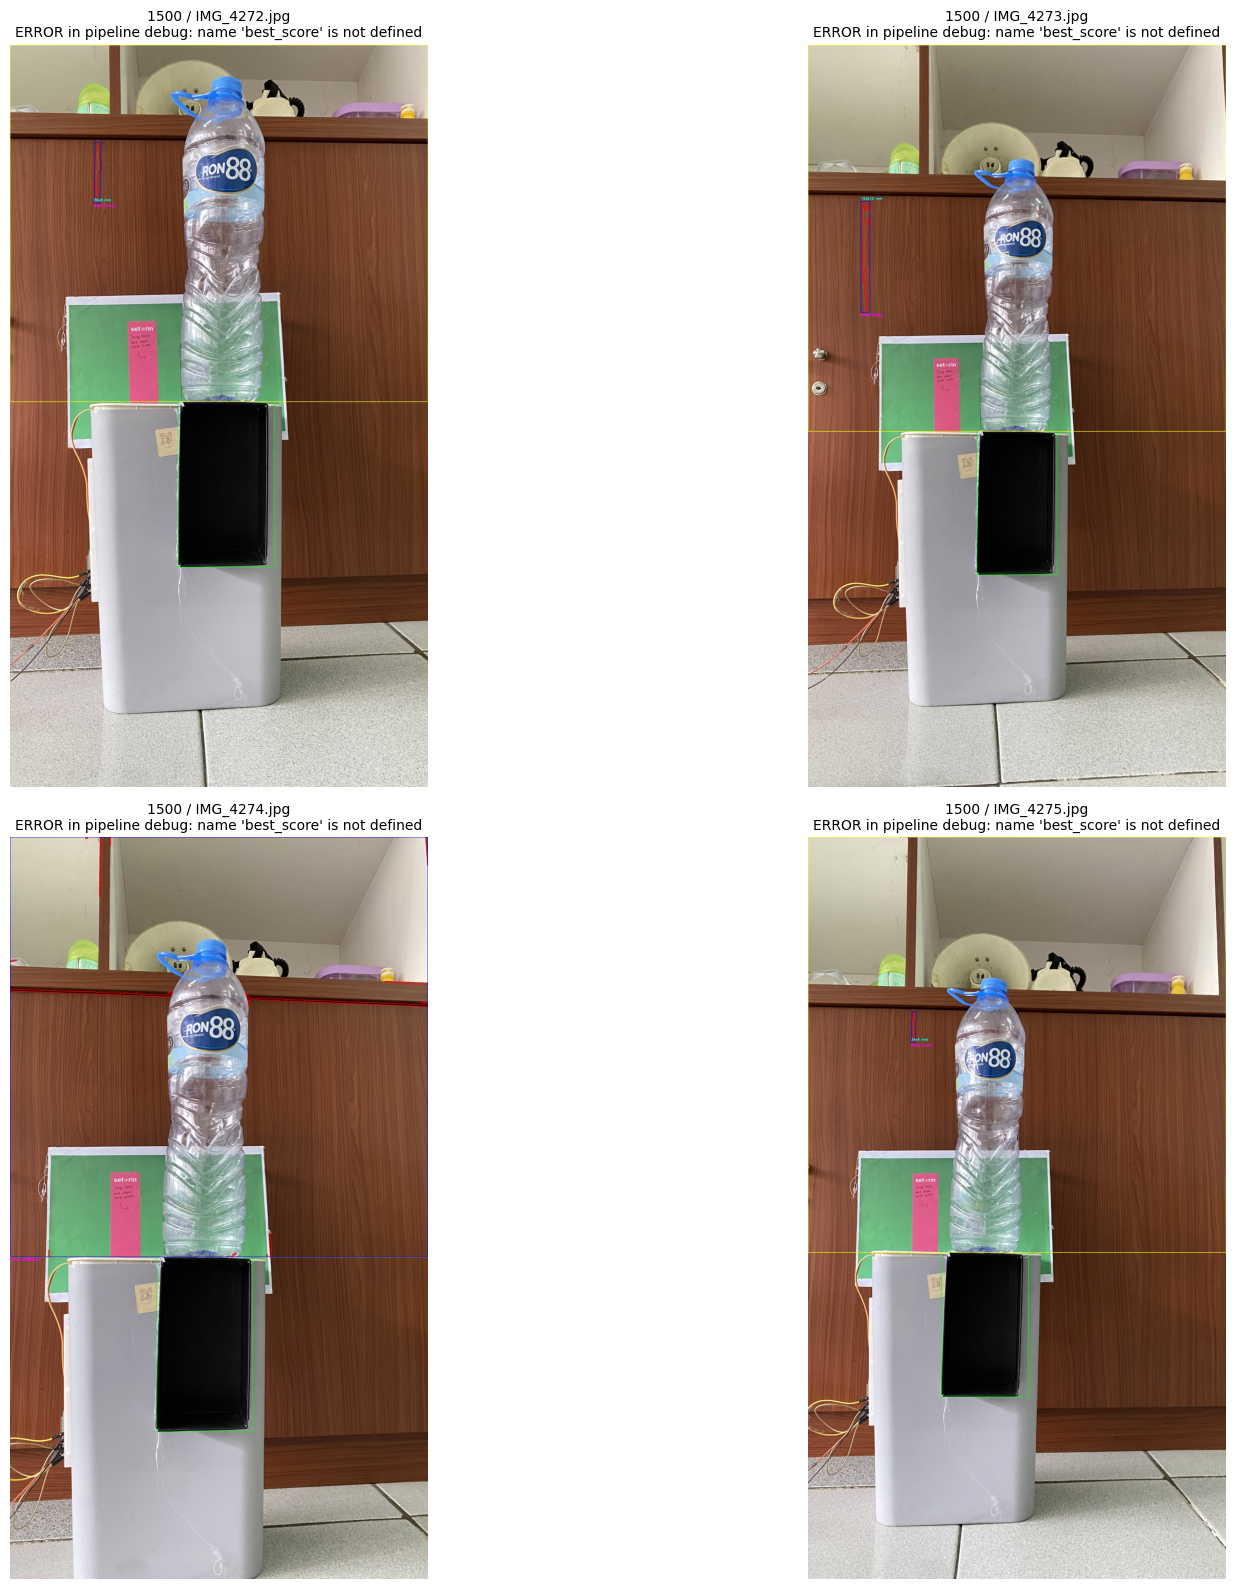

In [23]:
#@title Enhanced Debug Preview - Shows Pipeline Details
from PIL import Image
import matplotlib.pyplot as plt
import io

# Show debug images with pipeline breakdown
sample_paths = images[:4]  # Reduced to 4 since images will be larger
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

for ax, p in zip(axes.ravel(), sample_paths):
    try:
        expected = parse_expected_from_dir(p)
        img_bytes = imread_bytes(p)

        # Get predictions if using fusion
        preds = []
        if USE_FUSION and roboflow_client:
            try:
                import asyncio
                loop = asyncio.new_event_loop()
                asyncio.set_event_loop(loop)
                preds = loop.run_until_complete(roboflow_client.predict(img_bytes))
                loop.close()
            except:
                preds = []

        # Run measurement to get ROI
        result, debug_bytes = measurer.measure(img_bytes, predictions=preds, return_debug=True)

        # Get the ROI that was actually used
        nparr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        x_ref, y_ref, w_ref, h_ref = measurer._find_reference(hsv)

        # Extract ROI (simplified - using reference ROI for demo)
        if y_ref <= 0:
            roi = img
        else:
            roi = img[:y_ref, :]

        # Get enhanced debug from detector
        scale = measurer.ref_real_height_mm / h_ref
        pixel_per_cm = 10.0 / scale
        min_area_px = int((pixel_per_cm ** 2) * 0.5)

        try:
            _, pipeline_debug = measurer.detector.detect_with_debug(roi, min_area_px)
            debug_img = Image.open(io.BytesIO(pipeline_debug))
            ax.imshow(debug_img)

            title = f"{p.parent.name} / {p.name}\n"
            title += f"Expected: {expected}mL | Measured: {result.volume_ml:.0f}mL\n"
            title += f"Error: {abs(result.volume_ml - expected):.0f}mL" if expected else "No ground truth"

        except Exception as e:
            # Fallback to regular debug
            debug_img = Image.open(io.BytesIO(debug_bytes))
            ax.imshow(debug_img)
            title = f"{p.parent.name} / {p.name}\nERROR in pipeline debug: {str(e)[:50]}"

        ax.set_title(title, fontsize=10)
        ax.axis('off')

    except Exception as e:
        ax.imshow(Image.open(p))
        ax.set_title(f"{p.parent.name} / {p.name}\nERROR: {str(e)[:50]}", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

sweep 1.0,1.0,1.0,1.0,0.5:   0%|          | 0/90 [00:00<?, ?it/s]

sweep 1.0,1.5,1.0,1.0,0.5:   0%|          | 0/90 [00:00<?, ?it/s]

sweep 1.0,2.0,1.0,1.0,0.5:   0%|          | 0/90 [00:00<?, ?it/s]

sweep 1.0,1.0,1.5,1.0,0.5:   0%|          | 0/90 [00:00<?, ?it/s]

sweep 1.0,1.0,2.0,1.0,0.5:   0%|          | 0/90 [00:00<?, ?it/s]

sweep 1.0,1.0,1.0,1.5,0.5:   0%|          | 0/90 [00:00<?, ?it/s]

sweep 1.0,1.0,1.0,0.8,0.5:   0%|          | 0/90 [00:00<?, ?it/s]

sweep 1.0,1.0,1.0,1.0,1.0:   0%|          | 0/90 [00:00<?, ?it/s]

sweep 1.0,1.0,1.0,1.0,0.3:   0%|          | 0/90 [00:00<?, ?it/s]

,weights,mae_ml,mre_pct,rmse_ml,success_rate
0,"{'area': 1.0, 'aspect': 1.0, 'vertical': 1.0, ...",19105.742444,3302.440143,30338.392078,100.0
1,"{'area': 1.0, 'aspect': 1.5, 'vertical': 1.0, ...",17681.197667,3051.513080,29204.541756,100.0
2,"{'area': 1.0, 'aspect': 2.0, 'vertical': 1.0, ...",17681.834444,3051.622896,29204.558957,100.0
3,"{'area': 1.0, 'aspect': 1.0, 'vertical': 1.5, ...",17142.776444,2961.769795,28744.886712,100.0
4,"{'area': 1.0, 'aspect': 1.0, 'vertical': 2.0, ...",17142.773111,2961.769207,28744.886605,100.0
5,"{'area': 1.0, 'aspect': 1.0, 'vertical': 1.0, ...",25309.654333,4412.353767,35122.131840,100.0
6,"{'area': 1.0, 'aspect': 1.0, 'vertical': 1.0, ...",18804.514444,3252.235444,30197.563985,100.0
7,"{'area': 1.0, 'aspect': 1.0, 'vertical': 1.0, ...",15255.806778,2647.249492,26557.829936,100.0
8,"{'area': 1.0, 'aspect': 1.0, 'vertical': 1.0, ...",24634.765333,4286.396641,34569.232538,100.0


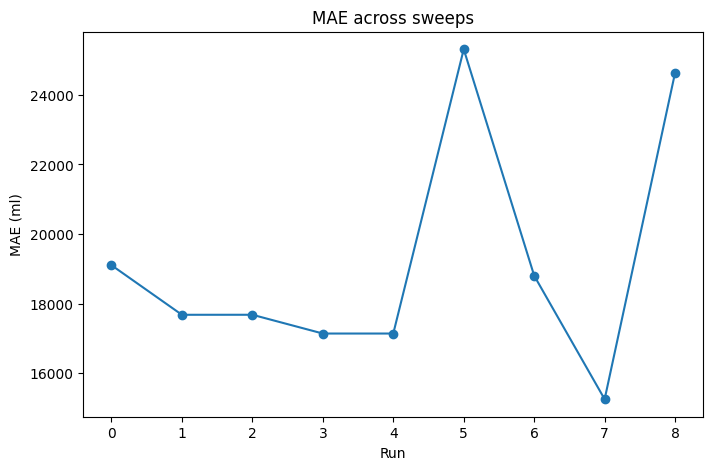

In [24]:
#@title Parameter sweep (single-parameter) and plots
from itertools import product

SWEEP = [
    (1.0, 1.0, 1.0, 1.0, 0.5),  # baseline
    (1.0, 1.5, 1.0, 1.0, 0.5),  # aspect+
    (1.0, 2.0, 1.0, 1.0, 0.5),  # aspect++
    (1.0, 1.0, 1.5, 1.0, 0.5),  # vertical+
    (1.0, 1.0, 2.0, 1.0, 0.5),  # vertical++
    (1.0, 1.0, 1.0, 1.5, 0.5),  # solidity+
    (1.0, 1.0, 1.0, 0.8, 0.5),  # solidity-
    (1.0, 1.0, 1.0, 1.0, 1.0),  # border+
    (1.0, 1.0, 1.0, 1.0, 0.3),  # border-
]

results_summary = []

for (wa, was, wv, wsol, wb) in SWEEP:
    sub_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    sub_path = RUN_DIR / f'sweep_{sub_ts}_{wa}_{was}_{wv}_{wsol}_{wb}'
    sub_path.mkdir(parents=True, exist_ok=True)
    dbg = sub_path / 'debug'
    if SAVE_DEBUG:
        dbg.mkdir(parents=True, exist_ok=True)

    cfg = {
        'weights': {'area': wa, 'aspect': was, 'vertical': wv, 'solidity': wsol, 'border': wb},
        'subset': SUBSET,
    }
    (sub_path / 'run_config.json').write_text(json.dumps(cfg, indent=2))

    meas = BottleMeasurer(
        detector_weight_area=wa,
        detector_weight_aspect=was,
        detector_weight_vertical=wv,
        detector_weight_solidity=wsol,
        detector_weight_border=wb,
    )

    rows = []
    for p in tqdm(images, desc=f"sweep {wa},{was},{wv},{wsol},{wb}", leave=False):
        expected = parse_expected_from_dir(p)
        img_bytes = imread_bytes(p)
        try:
            res, debug = meas.measure(img_bytes, return_debug=SAVE_DEBUG)
            debug_path = None
            if SAVE_DEBUG and debug is not None:
                name = p.stem + '_sweep.jpg'
                (dbg / name).write_bytes(debug)
                debug_path = str(dbg / name)
            error_ml = None if expected is None else abs(res.volume_ml - expected)
            rows.append([str(p), expected, res.volume_ml, res.diameter_mm, res.height_mm, error_ml, True, debug_path])
        except MeasurementError:
            rows.append([str(p), expected, None, None, None, None, False, None])

    df_s = pd.DataFrame(rows, columns=['image','expected_ml','measured_ml','diameter_mm','height_mm','error_ml','ok','debug_path'])
    df_s.to_csv(sub_path / 'measurements.csv', index=False)
    valid = df_s.dropna(subset=['error_ml'])
    mae = float(valid['error_ml'].mean()) if len(valid) else None
    mre = float((np.abs(valid['measured_ml'] - valid['expected_ml']) / valid['expected_ml'] * 100).mean()) if len(valid) else None
    rmse = float(np.sqrt(((valid['error_ml'] ** 2)).mean())) if len(valid) else None
    summary = {'weights': cfg['weights'], 'mae_ml': mae, 'mre_pct': mre, 'rmse_ml': rmse, 'success_rate': float(df_s['ok'].mean())*100}
    results_summary.append(summary)
    (sub_path / 'summary.json').write_text(json.dumps(summary, indent=2))

# Plot
if results_summary:
    plot_df = pd.DataFrame(results_summary)
    display(plot_df)
    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    ax.plot(range(len(plot_df)), plot_df['mae_ml'], marker='o')
    ax.set_title('MAE across sweeps')
    ax.set_xlabel('Run')
    ax.set_ylabel('MAE (ml)')
    plt.show()
